# Generative Adversarial Networks (GANs) in PyTorch

## Downloading and Exploring the Data

In [128]:
import os
import torch 
from torchvision.transforms import ToTensor, Normalize, Compose
from torchvision.datasets import MNIST
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torch.nn as nn
from IPython.display import Image
from torchvision.utils import save_image
import cv2
from IPython.display import FileLink

In [4]:
mnist = MNIST(root = "/data",
              train=True,
              download=True,
              transform=Compose([ToTensor(), Normalize(mean=(0.5,), std=(0.5,))]))

In [5]:
img, label = mnist[0]
print("Label: ", label)
print(img[:, 10:15, 10:15])
torch.min(img), torch.max(img)

Label:  5
tensor([[[-0.9922,  0.2078,  0.9843, -0.2941, -1.0000],
         [-1.0000,  0.0902,  0.9843,  0.4902, -0.9843],
         [-1.0000, -0.9137,  0.4902,  0.9843, -0.4510],
         [-1.0000, -1.0000, -0.7255,  0.8902,  0.7647],
         [-1.0000, -1.0000, -1.0000, -0.3647,  0.8824]]])


(tensor(-1.), tensor(1.))

In [6]:
def denorms(x):
    out = (x+1)/2
    return out.clamp(0, 1)

Label:  5


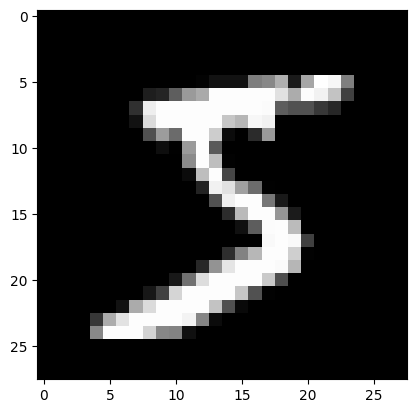

In [7]:
img_norm = denorms(img)
plt.imshow(img_norm[0], cmap="gray")
print("Label: ", label)

In [8]:
batch_size = 100

data_loader = DataLoader(mnist, batch_size, shuffle=True)

first batch
torch.Size([100, 1, 28, 28])
tensor([6, 7, 2, 7, 0, 2, 2, 3, 6, 1, 3, 0, 7, 5, 9, 2, 2, 3, 4, 4, 2, 3, 1, 0,
        3, 2, 1, 4, 3, 3, 6, 9, 1, 4, 6, 6, 0, 5, 7, 2, 6, 3, 4, 2, 9, 3, 8, 3,
        7, 0, 2, 9, 0, 9, 3, 2, 6, 7, 4, 8, 5, 2, 2, 1, 0, 2, 9, 4, 1, 3, 3, 3,
        2, 8, 6, 9, 9, 9, 9, 2, 3, 6, 1, 6, 8, 7, 4, 3, 8, 1, 8, 1, 7, 6, 3, 8,
        2, 8, 6, 1])


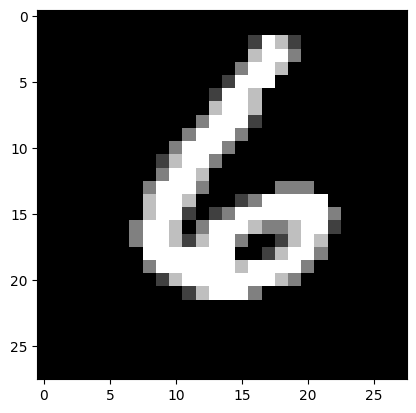

In [9]:
for img, label in data_loader:
    print("first batch")
    print(img.shape)
    print(label)
    plt.imshow(img[0][0], cmap="gray")
    break

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [11]:
device

device(type='cuda')

## Discrminator Network

In [13]:
image_size = 784
hidden_state = 256

In [14]:
D = nn.Sequential(
    nn.Linear(image_size, hidden_state),
    nn.LeakyReLU(0.2),
    nn.Linear(hidden_state, hidden_state),
    nn.LeakyReLU(0.2),
    nn.Linear(hidden_state, 1),
    nn.Sigmoid())

In [15]:
D.to(device)

Sequential(
  (0): Linear(in_features=784, out_features=256, bias=True)
  (1): LeakyReLU(negative_slope=0.2)
  (2): Linear(in_features=256, out_features=256, bias=True)
  (3): LeakyReLU(negative_slope=0.2)
  (4): Linear(in_features=256, out_features=1, bias=True)
  (5): Sigmoid()
)

In [16]:
latent_size = 64

In [17]:
G = nn.Sequential(
    nn.Linear(latent_size, hidden_state),
    nn.ReLU(),
    nn.Linear(hidden_state, hidden_state),
    nn.ReLU(),
    nn.Linear(hidden_state, image_size),
    nn.Tanh())

In [18]:
y = G(torch.randn(2, latent_size))
gen_imgs = denorms(y.reshape((-1, 28, 28)).detach())

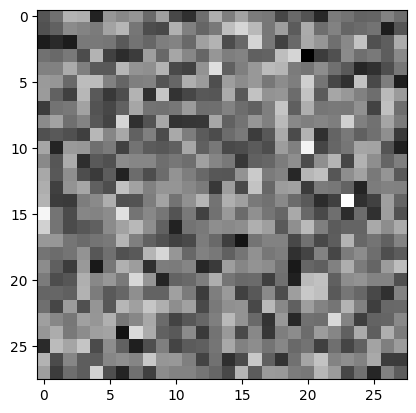

In [19]:
plt.imshow(gen_imgs[0], cmap="gray")

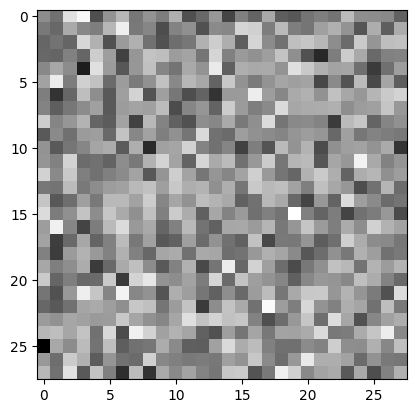

In [20]:
plt.imshow(gen_imgs[1], cmap="gray")

In [21]:
G.to(device)

Sequential(
  (0): Linear(in_features=64, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=256, bias=True)
  (3): ReLU()
  (4): Linear(in_features=256, out_features=784, bias=True)
  (5): Tanh()
)

## Discriminator Training

In [23]:
criterion = nn.BCELoss()
d_optimizer = torch.optim.Adam(D.parameters(), lr=0.0002)
g_optimizer = torch.optim.Adam(G.parameters(), lr=0.0002)

In [99]:
def reset_grad():
    d_optimizer.zero_grad()
    g_optimizer.zero_grad()

def train_discriminator(images):
    # Create the labels which are later used as input for the BCE loss
    real_labels = torch.ones(batch_size, 1).to(device)
    fake_labels = torch.zeros(batch_size, 1).to(device)

    #Loss for real images
    outputs = D(images)
    d_loss_real = criterion(outputs, real_labels)
    real_score = outputs

    # Loss for the fake images
    z = torch.randn(batch_size, latent_size).to(device)
    fake_images = G(z)
    outputs = D(fake_images)
    d_loss_fake = criterion(outputs, fake_labels)
    fake_score = outputs

    #Combine losses
    d_loss = d_loss_real + d_loss_fake
    #Reset Gradients
    reset_grad()
    # Compute gradients
    d_loss.backward()
    # Adjust the parameters using backprop
    d_optimizer.step()

    return d_loss, real_score, fake_score

## Generator Training

In [102]:
z = torch.randn(batch_size, latent_size).to(device)
fake_image = G(z)
D(fake_image)

tensor([[0.5196],
        [0.5186],
        [0.5166],
        [0.5141],
        [0.5157],
        [0.5158],
        [0.5186],
        [0.5207],
        [0.5189],
        [0.5190],
        [0.5180],
        [0.5167],
        [0.5197],
        [0.5163],
        [0.5183],
        [0.5159],
        [0.5198],
        [0.5171],
        [0.5184],
        [0.5152],
        [0.5148],
        [0.5176],
        [0.5164],
        [0.5184],
        [0.5166],
        [0.5185],
        [0.5194],
        [0.5162],
        [0.5191],
        [0.5166],
        [0.5191],
        [0.5154],
        [0.5201],
        [0.5172],
        [0.5184],
        [0.5179],
        [0.5217],
        [0.5164],
        [0.5163],
        [0.5182],
        [0.5185],
        [0.5184],
        [0.5173],
        [0.5175],
        [0.5174],
        [0.5169],
        [0.5185],
        [0.5174],
        [0.5166],
        [0.5163],
        [0.5177],
        [0.5154],
        [0.5192],
        [0.5185],
        [0.5182],
        [0

In [120]:
def train_generator():
    # Generate fake image and calculate loss
    z = torch.randn(batch_size, latent_size).to(device)
    fake_image = G(z)
    labels = torch.ones(batch_size, 1).to(device)
    g_loss = criterion(D(fake_image), labels)

    #Backprop and optimize
    reset_grad()
    g_loss.backward()
    g_optimizer.step()
    return g_loss, fake_image

## Training the Model

In [57]:
sample_dir = "samples"
if not os.path.exists(sample_dir):
    os.makedirs(sample_dir)

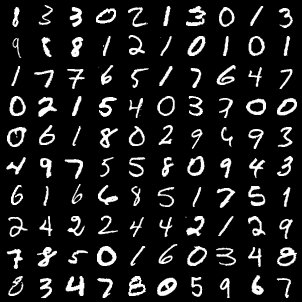

In [71]:
for images, _ in data_loader:
    images = images.reshape(images.size(0), 1, 28, 28)
    save_image(denorms(images), os.path.join(sample_dir, "real_images.png"), nrow=10)
    break

Image(os.path.join(sample_dir, "real_images.png"))

Saving fake_images-0000.png


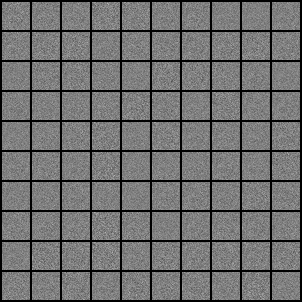

In [77]:
sample_vectors = torch.randn(batch_size, latent_size).to(device)

def save_fake_images(index):
    fake_images = G(sample_vectors)
    fake_images = fake_images.reshape(fake_images.size(0), 1, 28, 28)
    fake_fname = "fake_images-{0:0=4d}.png".format(index)
    print("Saving", fake_fname)
    save_image(denorms(fake_images), os.path.join(sample_dir, fake_fname), nrow=10)

#Before training
save_fake_images(0)
Image(os.path.join(sample_dir, "fake_images-0000.png"))

In [126]:
%time

epochs = 50
total_steps = len(data_loader)
d_losses, g_losses, real_scores, fake_scores = [], [], [], []

for epoch in range(epochs):
    for i, (images, _) in enumerate(data_loader):
        # Load a batch & transform to vectors
        images = images.reshape(batch_size, -1).to(device)

        #Train the discriminator and generator
        d_loss, real_score, fake_score = train_discriminator(images)
        g_loss, fake_images = train_generator()

        # Inspect the losses
        if (i+1) % 200 == 0:
            d_losses.append(d_loss.item())
            g_losses.append(g_loss.item())
            real_scores.append(real_score.mean().item())
            fake_scores.append(fake_score.mean().item())
            print("Epoch [{}/{}], Step [{}/{}], d_loss: {:.4f}, g_loss: {:.4f}, D(x): {:.2f}, D(G(x)): {:.2f}"
                  .format(epoch, num_epochs, i+1, total_steps, d_loss.item(), g_loss.item(),
                          real_score.mean().item(), fake_score.mean().item()))
    # Sample and save images
    save_fake_images(epoch+1)

CPU times: total: 0 ns
Wall time: 0 ns
Epoch [0/50], Step [200/600], d_loss: 0.0584, g_loss: 5.1438, D(x): 0.98, D(G(x)): 0.04
Epoch [0/50], Step [400/600], d_loss: 0.0515, g_loss: 5.1325, D(x): 0.98, D(G(x)): 0.03
Epoch [0/50], Step [600/600], d_loss: 0.0967, g_loss: 5.2462, D(x): 0.99, D(G(x)): 0.07
Saving fake_images-0001.png
Epoch [1/50], Step [200/600], d_loss: 0.1070, g_loss: 5.4047, D(x): 0.97, D(G(x)): 0.05
Epoch [1/50], Step [400/600], d_loss: 0.5403, g_loss: 4.4142, D(x): 0.92, D(G(x)): 0.25
Epoch [1/50], Step [600/600], d_loss: 0.7139, g_loss: 4.4923, D(x): 0.78, D(G(x)): 0.17
Saving fake_images-0002.png
Epoch [2/50], Step [200/600], d_loss: 1.0034, g_loss: 2.2604, D(x): 0.76, D(G(x)): 0.37
Epoch [2/50], Step [400/600], d_loss: 0.4635, g_loss: 2.9895, D(x): 0.88, D(G(x)): 0.19
Epoch [2/50], Step [600/600], d_loss: 0.3069, g_loss: 3.9016, D(x): 0.89, D(G(x)): 0.11
Saving fake_images-0003.png
Epoch [3/50], Step [200/600], d_loss: 1.2682, g_loss: 2.9872, D(x): 0.68, D(G(x)): 0.

## Visualize Progress

In [132]:
vid_fname = "gans_training.avi"

files = [os.path.join(sample_dir, f) for f in os.listdir(sample_dir) if "fake_images" in f]
files.sort()
files

['samples\\fake_images-0000.png',
 'samples\\fake_images-0001.png',
 'samples\\fake_images-0002.png',
 'samples\\fake_images-0003.png',
 'samples\\fake_images-0004.png',
 'samples\\fake_images-0005.png',
 'samples\\fake_images-0006.png',
 'samples\\fake_images-0007.png',
 'samples\\fake_images-0008.png',
 'samples\\fake_images-0009.png',
 'samples\\fake_images-0010.png',
 'samples\\fake_images-0011.png',
 'samples\\fake_images-0012.png',
 'samples\\fake_images-0013.png',
 'samples\\fake_images-0014.png',
 'samples\\fake_images-0015.png',
 'samples\\fake_images-0016.png',
 'samples\\fake_images-0017.png',
 'samples\\fake_images-0018.png',
 'samples\\fake_images-0019.png',
 'samples\\fake_images-0020.png',
 'samples\\fake_images-0021.png',
 'samples\\fake_images-0022.png',
 'samples\\fake_images-0023.png',
 'samples\\fake_images-0024.png',
 'samples\\fake_images-0025.png',
 'samples\\fake_images-0026.png',
 'samples\\fake_images-0027.png',
 'samples\\fake_images-0028.png',
 'samples\\fak

In [136]:
out = cv2.VideoWriter(vid_fname, cv2.VideoWriter_fourcc(*"MP4V"), 8, (302,302))
[out.write(cv2.imread(fname)) for fname in files]
out.release()
FileLink("gans_training.avi")

C:\Users\SHLOK\PyTorch\7 GANs\gans_training.avi

## Visualizing Loss and Scores

Text(0.5, 1.0, 'Losses')

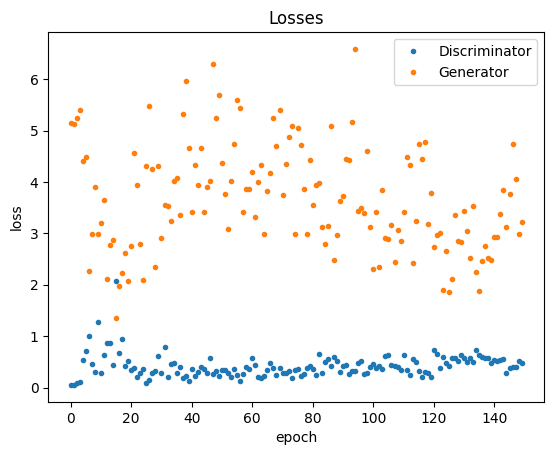

In [142]:
plt.plot(d_losses, ".")
plt.plot(g_losses, ".")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend(["Discriminator", "Generator"])
plt.title("Losses")

Text(0.5, 1.0, 'Scores')

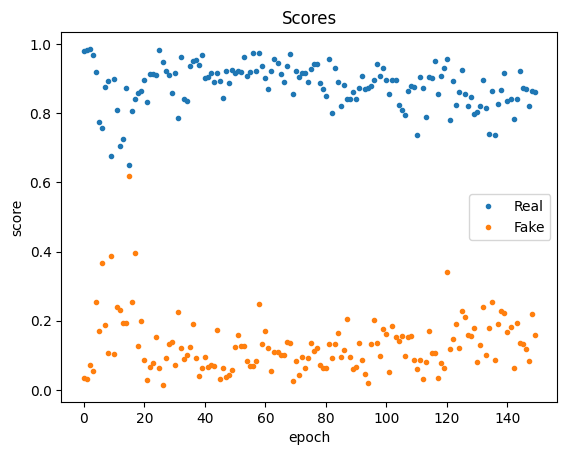

In [148]:
plt.plot(real_scores, ".")
plt.plot(fake_scores, ".")
plt.xlabel("epoch")
plt.ylabel("score")
plt.legend(["Real", "Fake"])
plt.title("Scores")